# Calidad y preparación de datos

Este notebook documenta exclusivamente la calidad, adecuación y preparación de los datos del análisis no supervisado. El proyecto integra detecciones FIRMS de focos de calor o anomalías térmicas con meteorología de Open-Meteo. FIRMS no representa automáticamente incendios confirmados. Los datos meteorológicos fueron preparados dentro del proyecto para compatibilidad temporal y espacial; no se atribuyen aquí detalles de reextracción que no estén verificables en el dataset. La unidad es **departamento–semana** para Uruguay. No se crea ni modifica ningún dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)

## 1. Carga y estructura

Se utiliza exactamente la misma fuente procesada que `Analisis_No_supervisado.ipynb`.

In [2]:
RUTA_DATOS = "data/processed/firms_open_meteo_weekly/open_meteo_firms_weekly_target_available.parquet"
datos = pd.read_parquet(RUTA_DATOS)
datos["fecha_inicio_semana"] = pd.to_datetime(datos["fecha_inicio_semana"], errors="raise")
datos["fecha_fin_semana"] = pd.to_datetime(datos["fecha_fin_semana"], errors="raise")

pd.DataFrame({
    "ruta": [RUTA_DATOS], "filas": [datos.shape[0]], "columnas": [datos.shape[1]],
    "fecha_minima": [datos["fecha_inicio_semana"].min()],
    "fecha_maxima": [datos["fecha_inicio_semana"].max()],
    "departamentos": [datos["departamento"].nunique()]
})

,ruta,filas,columnas,fecha_minima,fecha_maxima,departamentos
0,data/processed/firms_open_meteo_weekly/open_me...,7923,32,2018-01-01,2025-12-22,19


In [3]:
display(datos.shape)
display(datos.columns.tolist())
display(datos.dtypes.rename("tipo").to_frame())
datos.head()

(7923, 32)

['departamento', 'departamento_iso', 'fecha_inicio_semana', 'fecha_fin_semana', 'anio', 'numero_semana', 'n_dias_esperados', 'n_dias_observados', 'cobertura_temporal_pct', 'cobertura_espacial_min_pct', 'precipitation_days_weekly', 'temperature_2m_max_mean_weekly', 'temperature_2m_max_weekly', 'temperature_2m_min_mean_weekly', 'temperature_2m_min_weekly', 'relative_humidity_2m_min_mean_weekly', 'relative_humidity_2m_min_weekly', 'relative_humidity_2m_max_mean_weekly', 'relative_humidity_2m_max_weekly', 'wind_speed_10m_max_mean_weekly', 'wind_speed_10m_max_weekly', 'precipitation_sum_weekly', 'precipitation_max_daily_weekly', 'et0_fao_evapotranspiration_sum_weekly', 'et0_fao_evapotranspiration_max_daily_weekly', 'wind_direction_10m_resultant_length_spatial_daily_mean_weekly', 'wind_direction_10m_dominant_circular_mean_weekly', 'wind_direction_10m_resultant_length_weekly', 'cantidad_detecciones', 'nivel_actividad_firms', 'nivel_actividad_firms_codigo', 'target_firms_disponible']

,tipo
departamento,str
departamento_iso,str
fecha_inicio_semana,datetime64[us]
fecha_fin_semana,datetime64[us]
anio,int32
numero_semana,int64
n_dias_esperados,int64
n_dias_observados,int64
cobertura_temporal_pct,float64
cobertura_espacial_min_pct,float64


,departamento,departamento_iso,fecha_inicio_semana,fecha_fin_semana,anio,numero_semana,n_dias_esperados,n_dias_observados,cobertura_temporal_pct,cobertura_espacial_min_pct,precipitation_days_weekly,temperature_2m_max_mean_weekly,temperature_2m_max_weekly,temperature_2m_min_mean_weekly,temperature_2m_min_weekly,relative_humidity_2m_min_mean_weekly,relative_humidity_2m_min_weekly,relative_humidity_2m_max_mean_weekly,relative_humidity_2m_max_weekly,wind_speed_10m_max_mean_weekly,wind_speed_10m_max_weekly,precipitation_sum_weekly,precipitation_max_daily_weekly,et0_fao_evapotranspiration_sum_weekly,et0_fao_evapotranspiration_max_daily_weekly,wind_direction_10m_resultant_length_spatial_daily_mean_weekly,wind_direction_10m_dominant_circular_mean_weekly,wind_direction_10m_resultant_length_weekly,cantidad_detecciones,nivel_actividad_firms,nivel_actividad_firms_codigo,target_firms_disponible
0,Artigas,UY-AR,2018-01-01,2018-01-07,2018,1,7,7,100.0,100.0,3,30.764286,35.8,19.607143,15.7,32.959184,22,73.765306,96,6.566735,10.11,7.007143,4.585714,51.444286,9.26,0.996843,170.548873,0.296492,0,Sin detección,0,True
1,Artigas,UY-AR,2018-01-08,2018-01-14,2018,2,7,7,100.0,100.0,5,31.731633,35.7,22.044898,16.7,44.836735,22,78.765306,98,5.319592,7.43,32.842857,19.464286,43.183571,8.86,0.990082,82.423858,0.716303,0,Sin detección,0,True
2,Artigas,UY-AR,2018-01-15,2018-01-21,2018,3,7,7,100.0,100.0,6,29.744898,32.9,20.202041,17.3,44.469388,26,86.744898,97,5.492347,7.51,17.071429,15.364286,37.437143,7.35,0.996518,111.423557,0.674849,0,Sin detección,0,True
3,Artigas,UY-AR,2018-01-22,2018-01-28,2018,4,7,7,100.0,100.0,3,30.010204,33.3,20.647959,16.5,52.051020,37,90.755102,100,5.493673,7.62,25.335714,23.857143,38.801429,7.59,0.993956,92.446674,0.374700,0,Sin detección,0,True
4,Artigas,UY-AR,2018-01-29,2018-02-04,2018,5,7,7,100.0,100.0,0,31.524490,35.2,20.045918,16.4,37.132653,22,80.051020,91,5.431224,6.59,0.000000,0.000000,48.926429,7.70,0.998478,100.069495,0.974888,0,Sin detección,0,True


In [4]:
descripciones = {
    "departamento":"Nombre del departamento", "departamento_iso":"Identificador ISO del departamento",
    "fecha_inicio_semana":"Inicio de semana", "fecha_fin_semana":"Fin de semana",
    "anio":"Año", "numero_semana":"Número de semana",
    "n_dias_esperados":"Días esperados", "n_dias_observados":"Días observados",
    "cobertura_temporal_pct":"Cobertura temporal", "cobertura_espacial_min_pct":"Cobertura espacial mínima",
    "cantidad_detecciones":"Detecciones FIRMS semanales", "nivel_actividad_firms":"Nivel descriptivo FIRMS",
    "nivel_actividad_firms_codigo":"Código del nivel FIRMS", "target_firms_disponible":"Disponibilidad del target"
}
def rol_fuente(c):
    if c in ["departamento","departamento_iso"]: return "geográfico","Proyecto integrado"
    if c in ["fecha_inicio_semana","fecha_fin_semana","anio","numero_semana"]: return "temporal","Proyecto integrado"
    if c in ["cantidad_detecciones","nivel_actividad_firms","nivel_actividad_firms_codigo","target_firms_disponible"]: return "FIRMS","FIRMS/proceso derivado"
    if any(x in c for x in ["temperature","humidity","wind","precipitation","et0"]): return "meteorológico","Open-Meteo/proceso derivado"
    return "auxiliar/calidad","Proceso de preparación"

estructura=[]
for c in datos.columns:
    rol,fuente=rol_fuente(c)
    estructura.append([c,str(datos[c].dtype),descripciones.get(c,"Variable agregada identificada por su nombre técnico"),fuente,rol])
estructura=pd.DataFrame(estructura,columns=["variable","tipo","descripcion","fuente","rol"])
estructura

,variable,tipo,descripcion,fuente,rol
0,departamento,str,Nombre del departamento,Proyecto integrado,geográfico
1,departamento_iso,str,Identificador ISO del departamento,Proyecto integrado,geográfico
2,fecha_inicio_semana,datetime64[us],Inicio de semana,Proyecto integrado,temporal
3,fecha_fin_semana,datetime64[us],Fin de semana,Proyecto integrado,temporal
4,anio,int32,Año,Proyecto integrado,temporal
5,numero_semana,int64,Número de semana,Proyecto integrado,temporal
6,n_dias_esperados,int64,Días esperados,Proceso de preparación,auxiliar/calidad
7,n_dias_observados,int64,Días observados,Proceso de preparación,auxiliar/calidad
8,cobertura_temporal_pct,float64,Cobertura temporal,Proceso de preparación,auxiliar/calidad
9,cobertura_espacial_min_pct,float64,Cobertura espacial mínima,Proceso de preparación,auxiliar/calidad


## 2. Cobertura temporal y espacial

No se presupone que cada año tenga 52 semanas. Se cuentan las fechas reales y se verifica continuidad por diferencias de siete días dentro de cada departamento.

In [5]:
cobertura_anual=datos.groupby("anio").agg(
    observaciones=("fecha_inicio_semana","size"), semanas=("fecha_inicio_semana","nunique"),
    departamentos=("departamento","nunique"), fecha_minima=("fecha_inicio_semana","min"),
    fecha_maxima=("fecha_inicio_semana","max"), cobertura_temporal_min_pct=("cobertura_temporal_pct","min"),
    cobertura_espacial_min_pct=("cobertura_espacial_min_pct","min"))
cobertura_anual

,observaciones,semanas,departamentos,fecha_minima,fecha_maxima,cobertura_temporal_min_pct,cobertura_espacial_min_pct
anio,,,,,,,
2018,1007,53,19,2018-01-01,2018-12-31,100.0,100.0
2019,988,52,19,2019-01-07,2019-12-30,100.0,100.0
2020,988,52,19,2020-01-06,2020-12-28,100.0,100.0
2021,988,52,19,2021-01-04,2021-12-27,100.0,100.0
2022,988,52,19,2022-01-03,2022-12-26,100.0,100.0
2023,988,52,19,2023-01-02,2023-12-25,100.0,100.0
2024,1007,53,19,2024-01-01,2024-12-30,100.0,100.0
2025,969,51,19,2025-01-06,2025-12-22,100.0,100.0


In [6]:
cobertura_departamento=datos.groupby("departamento").agg(
    observaciones=("fecha_inicio_semana","size"), semanas=("fecha_inicio_semana","nunique"),
    fecha_minima=("fecha_inicio_semana","min"), fecha_maxima=("fecha_inicio_semana","max")).sort_index()
cobertura_departamento_anio=pd.crosstab(datos["departamento"],datos["anio"])
continuidad=[]
for depto,parte in datos.groupby("departamento"):
    dif=parte["fecha_inicio_semana"].drop_duplicates().sort_values().diff().dropna().dt.days
    continuidad.append([depto,len(dif),int(dif.ne(7).sum()),int(dif.max())])
continuidad=pd.DataFrame(continuidad,columns=["departamento","intervalos","intervalos_distintos_7_dias","salto_maximo_dias"])
display(cobertura_departamento)
display(cobertura_departamento_anio)
continuidad

,observaciones,semanas,fecha_minima,fecha_maxima
departamento,,,,
Artigas,417,417,2018-01-01,2025-12-22
Canelones,417,417,2018-01-01,2025-12-22
Cerro Largo,417,417,2018-01-01,2025-12-22
Colonia,417,417,2018-01-01,2025-12-22
Durazno,417,417,2018-01-01,2025-12-22
Flores,417,417,2018-01-01,2025-12-22
Florida,417,417,2018-01-01,2025-12-22
Lavalleja,417,417,2018-01-01,2025-12-22
Maldonado,417,417,2018-01-01,2025-12-22


anio,2018,2019,2020,2021,2022,2023,2024,2025
departamento,,,,,,,,
Artigas,53,52,52,52,52,52,53,51
Canelones,53,52,52,52,52,52,53,51
Cerro Largo,53,52,52,52,52,52,53,51
Colonia,53,52,52,52,52,52,53,51
Durazno,53,52,52,52,52,52,53,51
Flores,53,52,52,52,52,52,53,51
Florida,53,52,52,52,52,52,53,51
Lavalleja,53,52,52,52,52,52,53,51
Maldonado,53,52,52,52,52,52,53,51


,departamento,intervalos,intervalos_distintos_7_dias,salto_maximo_dias
0,Artigas,416,0,7
1,Canelones,416,0,7
2,Cerro Largo,416,0,7
3,Colonia,416,0,7
4,Durazno,416,0,7
5,Flores,416,0,7
6,Florida,416,0,7
7,Lavalleja,416,0,7
8,Maldonado,416,0,7
9,Montevideo,416,0,7


cell_9:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


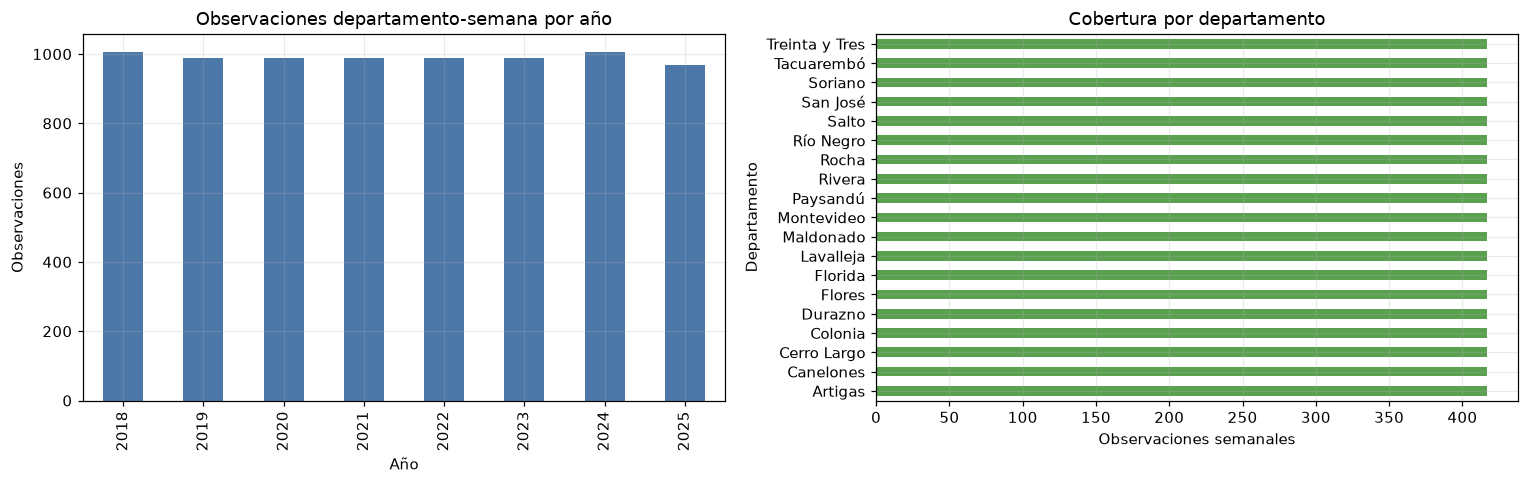

In [7]:
fig,axes=plt.subplots(1,2,figsize=(14,4.5))
cobertura_anual["observaciones"].plot(kind="bar",ax=axes[0],color="#4c78a8")
axes[0].set(title="Observaciones departamento-semana por año",xlabel="Año",ylabel="Observaciones")
cobertura_departamento["observaciones"].sort_values().plot(kind="barh",ax=axes[1],color="#59a14f")
axes[1].set(title="Cobertura por departamento",xlabel="Observaciones semanales",ylabel="Departamento")
for ax in axes: ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

Los gráficos comparan la cobertura real; la tabla de continuidad es la evidencia para detectar saltos semanales.

## 3. Faltantes e imputación

La imputación sólo corresponde si las variables finales lo requieren; no se aplica para demostrar una técnica.

In [8]:
faltantes=pd.DataFrame({"n_total":len(datos),"n_disponibles":datos.notna().sum(),"n_faltantes":datos.isna().sum()})
faltantes["faltantes_pct"]=faltantes["n_faltantes"]/faltantes["n_total"]*100
faltantes["cobertura_pct"]=faltantes["n_disponibles"]/faltantes["n_total"]*100
faltantes=faltantes.sort_values("faltantes_pct",ascending=False)
faltantes

,n_total,n_disponibles,n_faltantes,faltantes_pct,cobertura_pct
departamento,7923,7923,0,0.0,100.0
departamento_iso,7923,7923,0,0.0,100.0
fecha_inicio_semana,7923,7923,0,0.0,100.0
fecha_fin_semana,7923,7923,0,0.0,100.0
anio,7923,7923,0,0.0,100.0
numero_semana,7923,7923,0,0.0,100.0
n_dias_esperados,7923,7923,0,0.0,100.0
n_dias_observados,7923,7923,0,0.0,100.0
cobertura_temporal_pct,7923,7923,0,0.0,100.0
cobertura_espacial_min_pct,7923,7923,0,0.0,100.0


Faltantes en variables finales: 0
cell_13:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


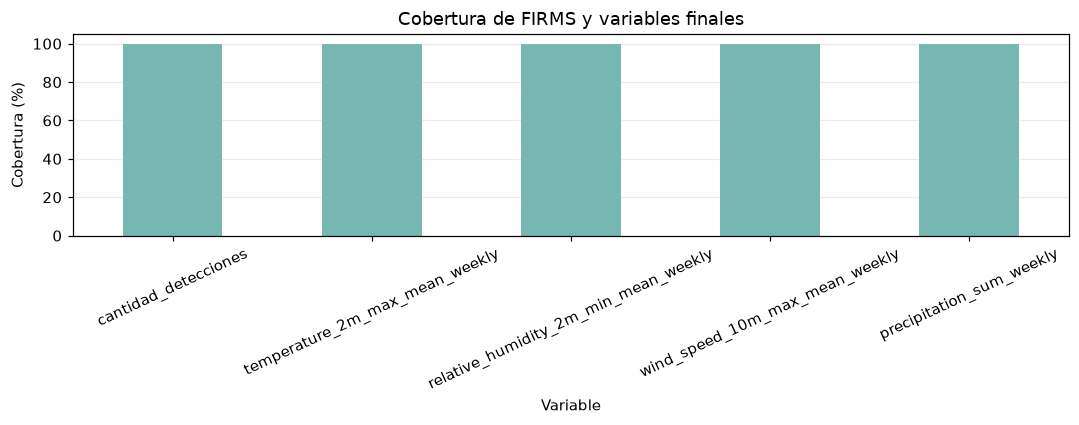

In [9]:
variables_finales=["temperature_2m_max_mean_weekly","relative_humidity_2m_min_mean_weekly","wind_speed_10m_max_mean_weekly","precipitation_sum_weekly"]
variables_grafico=["cantidad_detecciones",*variables_finales]
fig,ax=plt.subplots(figsize=(10,4))
faltantes.loc[variables_grafico,"cobertura_pct"].plot(kind="bar",ax=ax,color="#76b7b2")
ax.set(title="Cobertura de FIRMS y variables finales",xlabel="Variable",ylabel="Cobertura (%)",ylim=(0,105))
ax.tick_params(axis="x",rotation=25); ax.grid(axis="y",alpha=.25); plt.tight_layout(); plt.show()
print("Faltantes en variables finales:",int(datos[variables_finales].isna().sum().sum()))

Si las cuatro variables finales tienen 100% de cobertura, **no fue necesario aplicar imputación**. Introducir valores artificiales alteraría distancias sin aportar información.

## 4. Duplicados y claves

In [10]:
duplicados_exactos=int(datos.duplicated().sum())
mascara_clave=datos.duplicated(["departamento","fecha_inicio_semana"],keep=False)
duplicados_clave=int(mascara_clave.sum())
claves_repetidas=int(datos.loc[mascara_clave,["departamento","fecha_inicio_semana"]].drop_duplicates().shape[0])
pd.DataFrame({"control":["Filas exactas duplicadas","Filas en claves duplicadas","Claves duplicadas distintas"],"cantidad":[duplicados_exactos,duplicados_clave,claves_repetidas]})

,control,cantidad
0,Filas exactas duplicadas,0
1,Filas en claves duplicadas,0
2,Claves duplicadas distintas,0


## 5. Valores imposibles y extremos

Conteos, precipitación y viento no pueden ser negativos; humedad debe estar entre 0% y 100%. Para temperatura no se inventa un umbral físico: se identifican extremos estadísticos mediante 1,5 IQR, que se conservan como valores posibles sujetos a revisión.

In [11]:
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

temp = datos["temperature_2m_max_mean_weekly"]
li_temp, ls_temp = limites_iqr(temp)
firms = datos["cantidad_detecciones"].astype(float)
li_firms, ls_firms = limites_iqr(firms)
precip = datos["precipitation_sum_weekly"]
li_precip, ls_precip = limites_iqr(precip)

auditoria_rangos = pd.DataFrame([
    ["cantidad_detecciones", firms.min(), firms.max(), int(firms.lt(0).sum()), int((firms.lt(li_firms) | firms.gt(ls_firms)).sum()), f"Sin negativos; {ls_firms:.2f} es límite IQR. Conservar extremos positivos"],
    ["precipitation_sum_weekly", precip.min(), precip.max(), int(precip.lt(0).sum()), int((precip.lt(li_precip) | precip.gt(ls_precip)).sum()), f"Sin negativos; {ls_precip:.2f} es límite IQR. Conservar extremos"],
    ["relative_humidity_2m_min_mean_weekly", datos.relative_humidity_2m_min_mean_weekly.min(), datos.relative_humidity_2m_min_mean_weekly.max(), int((~datos.relative_humidity_2m_min_mean_weekly.between(0,100)).sum()), np.nan, "Valores fuera de 0–100% serían imposibles"],
    ["wind_speed_10m_max_mean_weekly", datos.wind_speed_10m_max_mean_weekly.min(), datos.wind_speed_10m_max_mean_weekly.max(), int(datos.wind_speed_10m_max_mean_weekly.lt(0).sum()), np.nan, "Valores negativos serían imposibles"],
    ["temperature_2m_max_mean_weekly", temp.min(), temp.max(), np.nan, int((temp.lt(li_temp) | temp.gt(ls_temp)).sum()), f"Extremos IQR fuera de [{li_temp:.2f}, {ls_temp:.2f}]; conservar"]
], columns=["variable","minimo","maximo","valores_imposibles","extremos_estadisticos","decision"])
auditoria_rangos.round(3)

,variable,minimo,maximo,valores_imposibles,extremos_estadisticos,decision
0,cantidad_detecciones,0.000,173.000,0.0,1060.0,Sin negativos; 2.50 es límite IQR. Conservar e...
1,precipitation_sum_weekly,0.000,200.350,0.0,375.0,Sin negativos; 71.85 es límite IQR. Conservar ...
2,relative_humidity_2m_min_mean_weekly,21.562,88.286,0.0,NaN,Valores fuera de 0–100% serían imposibles
3,wind_speed_10m_max_mean_weekly,2.886,9.751,0.0,NaN,Valores negativos serían imposibles
4,temperature_2m_max_mean_weekly,8.829,37.302,NaN,0.0,"Extremos IQR fuera de [4.82, 39.31]; conservar"


## 6. Estadísticos y distribuciones

In [12]:
variables_descriptivas=["cantidad_detecciones",*variables_finales,"et0_fao_evapotranspiration_sum_weekly"]
filas=[]
for v in variables_descriptivas:
    x=datos[v].astype(float)
    filas.append([v,x.count(),x.mean(),x.median(),x.std(),x.min(),x.quantile(.25),x.quantile(.75),x.quantile(.90),x.quantile(.95),x.max(),x.skew()])
descriptivos=pd.DataFrame(filas,columns=["variable","count","media","mediana","std","min","p25","p75","p90","p95","max","skewness"]).set_index("variable")
descriptivos.round(3)

,count,media,mediana,std,min,p25,p75,p90,p95,max,skewness
variable,,,,,,,,,,,
cantidad_detecciones,7923,1.074,0.000,3.144,0.000,0.000,1.000,3.000,5.000,173.000,26.159
temperature_2m_max_mean_weekly,7923,22.067,21.986,5.497,8.829,17.755,26.378,29.361,30.757,37.302,0.043
relative_humidity_2m_min_mean_weekly,7923,55.064,56.102,10.356,21.562,48.601,62.652,67.815,70.082,88.286,-0.430
wind_speed_10m_max_mean_weekly,7923,5.498,5.483,0.876,2.886,4.922,6.064,6.598,6.950,9.751,0.123
precipitation_sum_weekly,7923,20.757,11.819,25.067,0.000,2.670,30.342,53.480,70.765,200.350,2.136
et0_fao_evapotranspiration_sum_weekly,7923,23.992,22.068,11.811,3.862,13.441,33.320,40.945,44.777,62.952,0.481


cell_21:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


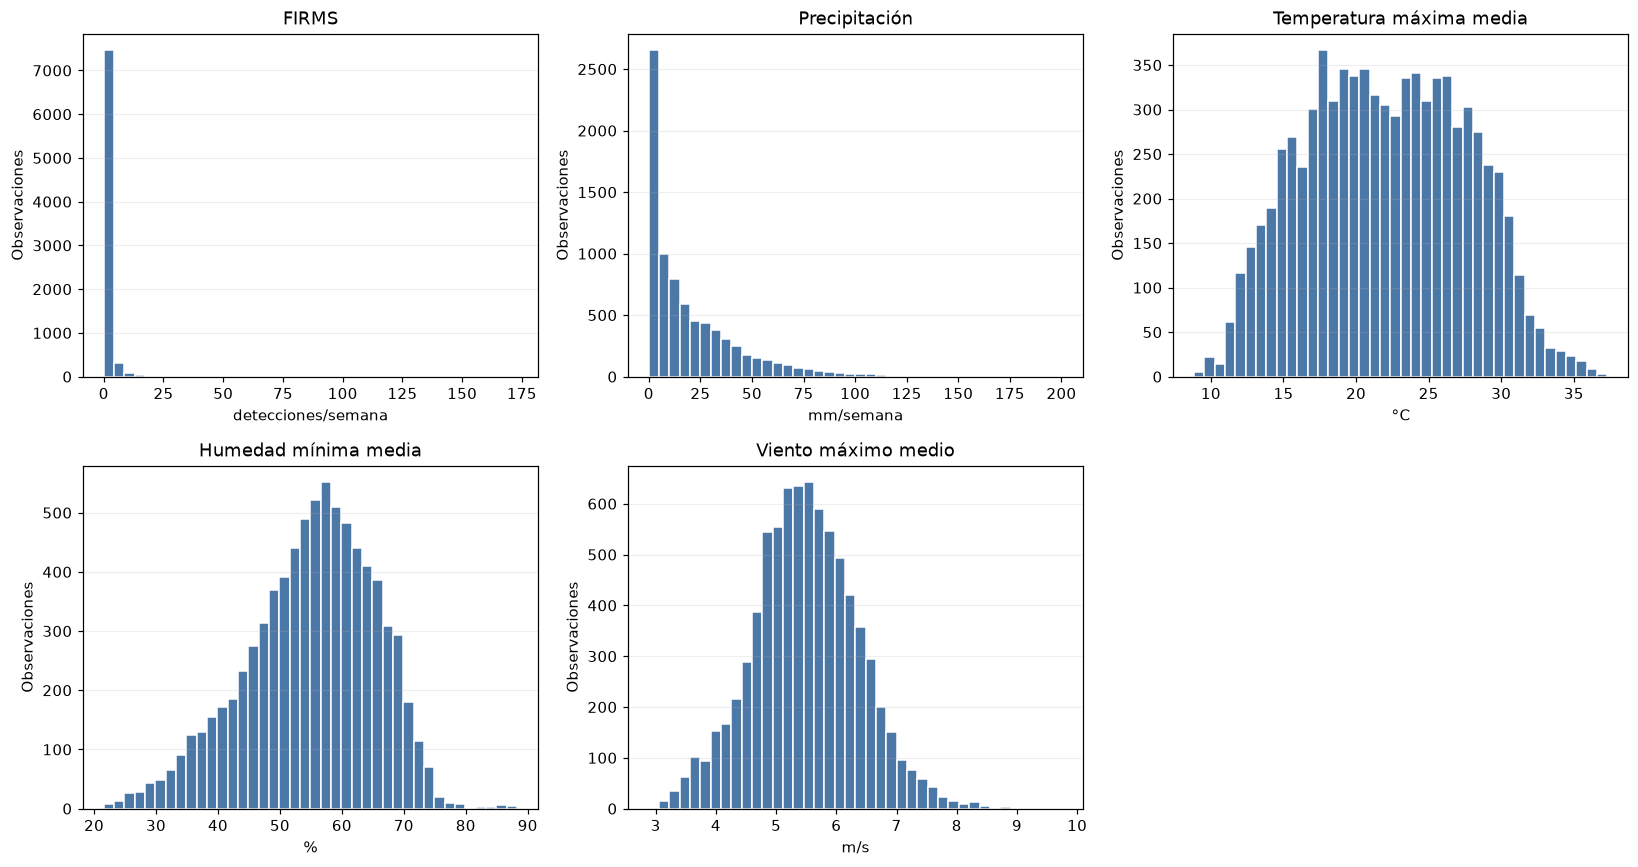

In [13]:
fig,axes=plt.subplots(2,3,figsize=(15,8))
gs=[("cantidad_detecciones","FIRMS","detecciones/semana"),("precipitation_sum_weekly","Precipitación","mm/semana"),("temperature_2m_max_mean_weekly","Temperatura máxima media","°C"),("relative_humidity_2m_min_mean_weekly","Humedad mínima media","%"),("wind_speed_10m_max_mean_weekly","Viento máximo medio","m/s")]
for ax,(v,t,u) in zip(axes.ravel(),gs):
    ax.hist(datos[v],bins=40,color="#4c78a8",edgecolor="white"); ax.set(title=t,xlabel=u,ylabel="Observaciones"); ax.grid(axis="y",alpha=.2)
axes[1,2].axis("off"); plt.tight_layout(); plt.show()

## 7. Justificación de `log1p`

Se evalúa sólo en variables no negativas con asimetría positiva. FIRMS se transforma como diagnóstico, pero no es entrada del clustering meteorológico.

In [14]:
transformaciones=[]
for v in ["cantidad_detecciones","precipitation_sum_weekly"]:
    x=datos[v].astype(float); xt=np.log1p(x)
    transformaciones.append([v,x.skew(),"log1p",xt.skew(),"Sólo diagnóstico" if v=="cantidad_detecciones" else "Entrada del clustering"])
tabla_transformaciones=pd.DataFrame(transformaciones,columns=["variable","skewness_original","transformacion","skewness_transformada","motivo"])
tabla_transformaciones.round(3)

,variable,skewness_original,transformacion,skewness_transformada,motivo
0,cantidad_detecciones,26.159,log1p,1.455,Sólo diagnóstico
1,precipitation_sum_weekly,2.136,log1p,-0.262,Entrada del clustering


cell_24:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


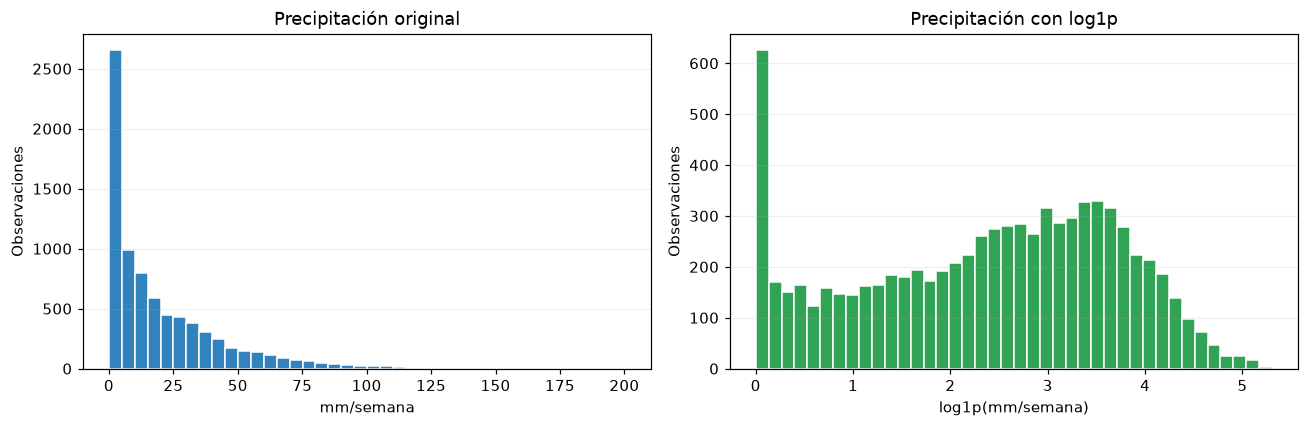

In [15]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(datos.precipitation_sum_weekly,bins=40,color="#3182bd",edgecolor="white"); axes[0].set(title="Precipitación original",xlabel="mm/semana",ylabel="Observaciones")
axes[1].hist(np.log1p(datos.precipitation_sum_weekly),bins=40,color="#31a354",edgecolor="white"); axes[1].set(title="Precipitación con log1p",xlabel="log1p(mm/semana)",ylabel="Observaciones")
for ax in axes: ax.grid(axis="y",alpha=.2)
plt.tight_layout(); plt.show()

## 8. Correlaciones y selección

Spearman resulta apropiada ante asimetría y relaciones monotónicas. Se auditan alternativas de temperatura, humedad, viento, precipitación y ET0 para evitar sobreponderar dimensiones redundantes.

In [16]:
variables_correlacion=["temperature_2m_max_mean_weekly","temperature_2m_max_weekly","temperature_2m_min_mean_weekly","relative_humidity_2m_min_mean_weekly","relative_humidity_2m_min_weekly","relative_humidity_2m_max_mean_weekly","wind_speed_10m_max_mean_weekly","wind_speed_10m_max_weekly","precipitation_sum_weekly","precipitation_max_daily_weekly","et0_fao_evapotranspiration_sum_weekly"]
corr=datos[variables_correlacion].corr(method="spearman")
pares=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)).stack()
pares_relevantes=pares[pares.abs().ge(.70)].sort_values(key=lambda x:x.abs(),ascending=False).rename("rho_spearman").reset_index()
pares_relevantes.columns=["variable_1","variable_2","rho_spearman"]
pares_relevantes.round(3)

,variable_1,variable_2,rho_spearman
0,precipitation_sum_weekly,precipitation_max_daily_weekly,0.978
1,temperature_2m_max_mean_weekly,temperature_2m_max_weekly,0.953
2,temperature_2m_max_mean_weekly,temperature_2m_min_mean_weekly,0.936
3,temperature_2m_max_mean_weekly,et0_fao_evapotranspiration_sum_weekly,0.883
4,temperature_2m_max_weekly,temperature_2m_min_mean_weekly,0.878
5,relative_humidity_2m_min_mean_weekly,relative_humidity_2m_min_weekly,0.871
6,temperature_2m_max_weekly,et0_fao_evapotranspiration_sum_weekly,0.859
7,relative_humidity_2m_min_mean_weekly,et0_fao_evapotranspiration_sum_weekly,-0.803
8,temperature_2m_min_mean_weekly,et0_fao_evapotranspiration_sum_weekly,0.748
9,relative_humidity_2m_min_weekly,et0_fao_evapotranspiration_sum_weekly,-0.742


cell_27:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


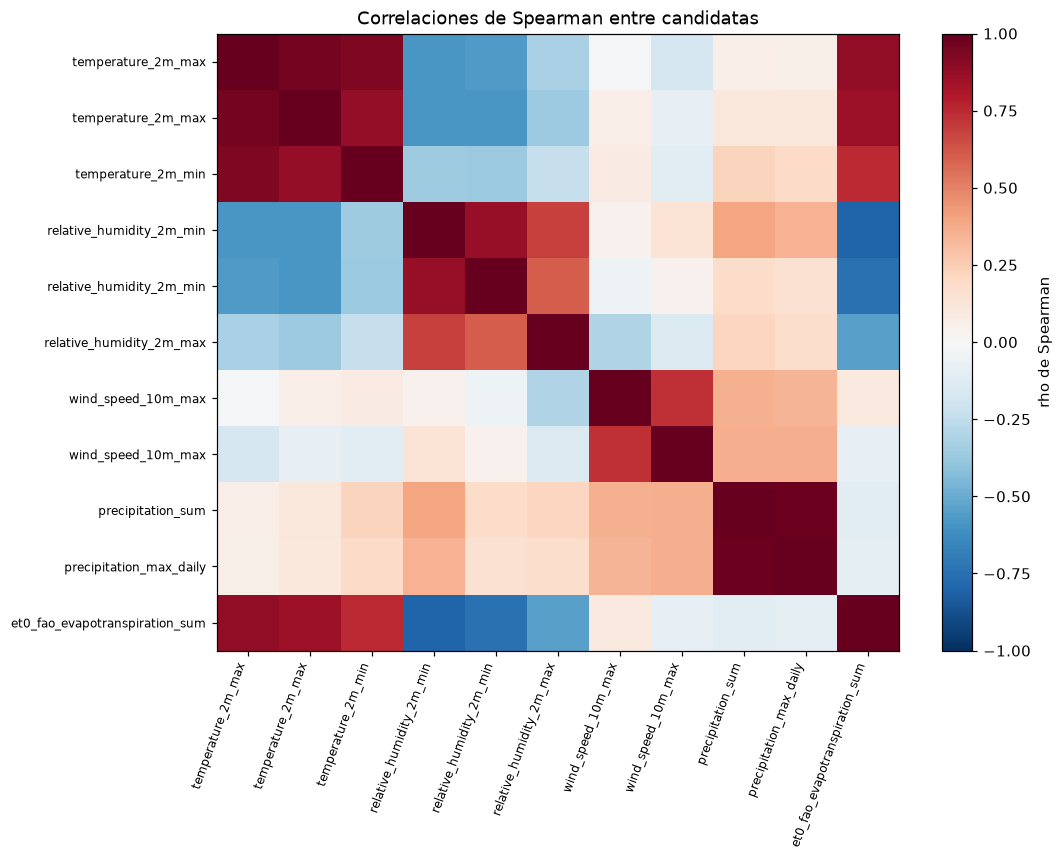

In [17]:
fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(corr,cmap="RdBu_r",vmin=-1,vmax=1,aspect="auto")
labs=[v.replace("_weekly","").replace("_mean","") for v in variables_correlacion]
ax.set_xticks(range(len(labs)),labels=labs,rotation=70,ha="right",fontsize=8); ax.set_yticks(range(len(labs)),labels=labs,fontsize=8)
ax.set_title("Correlaciones de Spearman entre candidatas"); fig.colorbar(im,ax=ax,label="rho de Spearman"); plt.tight_layout(); plt.show()

In [18]:
seleccion=[]
for v in variables_correlacion:
    incluida=v in variables_finales
    if incluida: just="Resumen seleccionado para esta dimensión meteorológica"
    elif v=="et0_fao_evapotranspiration_sum_weekly": just="Derivada y correlacionada; evita sobreponderación"
    else: just="Alternativa redundante con un resumen seleccionado"
    seleccion.append([v,datos[v].notna().mean()*100,datos[v].skew(),corr[v].drop(v).abs().max(),"Sí" if incluida else "No",just])
seleccion=pd.DataFrame(seleccion,columns=["variable","cobertura_pct","asimetria","max_correlacion_abs_spearman","incluida","justificacion"])
seleccion.round(3)

,variable,cobertura_pct,asimetria,max_correlacion_abs_spearman,incluida,justificacion
0,temperature_2m_max_mean_weekly,100.0,0.043,0.953,Sí,Resumen seleccionado para esta dimensión meteo...
1,temperature_2m_max_weekly,100.0,-0.127,0.953,No,Alternativa redundante con un resumen seleccio...
2,temperature_2m_min_mean_weekly,100.0,-0.040,0.936,No,Alternativa redundante con un resumen seleccio...
3,relative_humidity_2m_min_mean_weekly,100.0,-0.430,0.871,Sí,Resumen seleccionado para esta dimensión meteo...
4,relative_humidity_2m_min_weekly,100.0,-0.277,0.871,No,Alternativa redundante con un resumen seleccio...
5,relative_humidity_2m_max_mean_weekly,100.0,-1.322,0.682,No,Alternativa redundante con un resumen seleccio...
6,wind_speed_10m_max_mean_weekly,100.0,0.123,0.734,Sí,Resumen seleccionado para esta dimensión meteo...
7,wind_speed_10m_max_weekly,100.0,0.651,0.734,No,Alternativa redundante con un resumen seleccio...
8,precipitation_sum_weekly,100.0,2.136,0.978,Sí,Resumen seleccionado para esta dimensión meteo...
9,precipitation_max_daily_weekly,100.0,1.732,0.978,No,Alternativa redundante con un resumen seleccio...


## 9. Matriz final, separación temporal y escalado

La matriz contiene sólo las cuatro variables meteorológicas seleccionadas. Se aplica `log1p` únicamente a precipitación. El scaler se ajusta con 2018–2023 y sólo transforma 2024–2025. Aquí no se entrena K-Means.

In [19]:
desarrollo=datos[datos.fecha_inicio_semana.between("2018-01-01","2023-12-31")].copy()
externo=datos[datos.fecha_inicio_semana.between("2024-01-01","2025-12-31")].copy()
def preparar(df):
    X=df[variables_finales].astype(float).copy(); X["precipitation_sum_weekly"]=np.log1p(X["precipitation_sum_weekly"]); return X
X_dev=preparar(desarrollo); X_ext=preparar(externo)
scaler=StandardScaler(); X_dev_scaled=scaler.fit_transform(X_dev); X_ext_scaled=scaler.transform(X_ext)
pd.DataFrame({"particion":["desarrollo","externo"],"inicio":[desarrollo.fecha_inicio_semana.min(),externo.fecha_inicio_semana.min()],"fin":[desarrollo.fecha_inicio_semana.max(),externo.fecha_inicio_semana.max()],"observaciones":[len(desarrollo),len(externo)]})

,particion,inicio,fin,observaciones
0,desarrollo,2018-01-01,2023-12-25,5947
1,externo,2024-01-01,2025-12-22,1976


In [20]:
efecto_scaler=pd.DataFrame({"variable":variables_finales,"media_original":X_dev.mean().values,"std_original":X_dev.std(ddof=0).values,"media_escalada":X_dev_scaled.mean(axis=0),"std_escalada":X_dev_scaled.std(axis=0),"media_externa_sin_reajuste":X_ext_scaled.mean(axis=0),"std_externa_sin_reajuste":X_ext_scaled.std(axis=0)})
efecto_scaler.round(4)

,variable,media_original,std_original,media_escalada,std_escalada,media_externa_sin_reajuste,std_externa_sin_reajuste
0,temperature_2m_max_mean_weekly,22.0897,5.4747,0.0,1.0,-0.0169,1.0157
1,relative_humidity_2m_min_mean_weekly,54.4965,10.7092,-0.0,1.0,0.2125,0.8397
2,wind_speed_10m_max_mean_weekly,5.4966,0.8672,-0.0,1.0,0.0062,1.0418
3,precipitation_sum_weekly,2.3251,1.3361,0.0,1.0,0.1046,0.9867


### Imputación, codificación y balanceo

- **Imputación:** no necesaria si la matriz final presenta cobertura completa.
- **Codificación:** departamento, mes y estación no entran al clustering; no se requiere OneHotEncoder ni codificación ordinal.
- **Balanceo:** no corresponde aplicar SMOTE, oversampling o undersampling en una etapa no supervisada sin clase objetivo. Se evaluará posteriormente sólo si el target supervisado definitivo lo requiere.

## 10. PCA sólo para visualización

PCA resume la matriz estandarizada de desarrollo, pero no es una transformación obligatoria ni la entrada del clustering principal.

cell_34:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.4429,0.4429
1,PC2,0.3229,0.7658


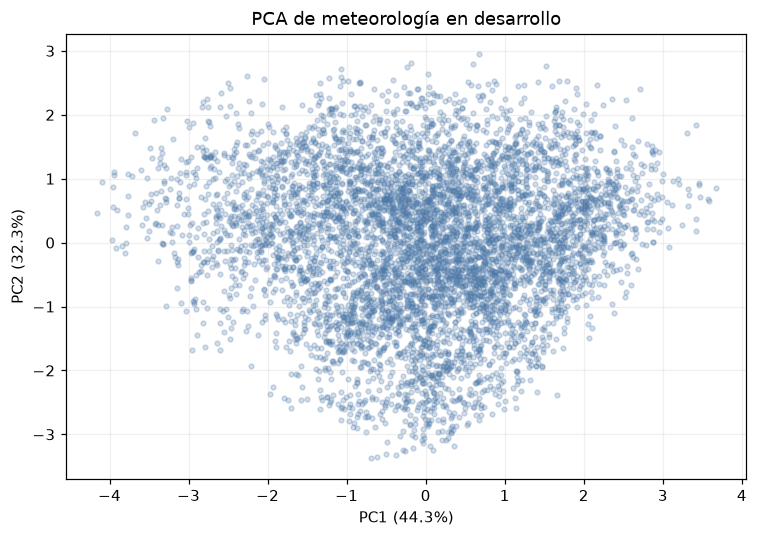

In [21]:
pca=PCA(n_components=2); comp=pca.fit_transform(X_dev_scaled)
varianza_pca=pd.DataFrame({"componente":["PC1","PC2"],"varianza_explicada":pca.explained_variance_ratio_,"varianza_acumulada":np.cumsum(pca.explained_variance_ratio_)})
display(varianza_pca.round(4))
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(comp[:,0],comp[:,1],s=10,alpha=.25,color="#4c78a8")
ax.set(title="PCA de meteorología en desarrollo",xlabel=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",ylabel=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## 11. Variables construidas y roles

- La unidad departamento–semana y las agregaciones semanales ya están materializadas.
- `log1p(precipitation_sum_weekly)` sí entra al clustering.
- Mes y estación se derivan sólo para interpretación.
- El proxy semanal inspirado en Nesterov es interpretativo, no entrada y no índice oficial.
- FIRMS se mantiene fuera de X y se usa posteriormente como contraste externo.

## 12. Limitaciones

- FIRMS detecta anomalías térmicas, no incendios confirmados.
- La agregación departamento–semana reduce resolución espacial y temporal y puede suavizar extremos diarios.
- Puede existir heterogeneidad meteorológica dentro de un departamento.
- Open-Meteo aporta información meteorológica modelada, no necesariamente medición puntual.
- Existe estructura estacional en la meteorología.
- El proxy semanal de Nesterov no reproduce el índice oficial.
- Las asociaciones observadas no implican causalidad.

## 13. Checklist final

In [22]:
checklist=pd.DataFrame([
 ["Carga reproducible","Sí","Parquet procesado oficial sin modificar"],["Cobertura","Sí","Temporal y espacial auditada"],["Duplicados","Sí","Filas y clave auditadas"],["Faltantes","Sí","Todas las columnas"],["Rangos","Sí","Imposibles y extremos diferenciados"],["Imputación","No necesaria","Variables finales completas"],["log1p","Sí","Precipitación; FIRMS sólo diagnóstico"],["Codificación","No necesaria","Categorías fuera de X"],["StandardScaler","Sí","Fit sólo 2018–2023"],["Balanceo","No corresponde","Etapa no supervisada"],["Selección","Sí","Cuatro dimensiones parsimoniosas"],["PCA","Sólo visualización","No entra al clustering"],["Separación temporal","Sí","Desarrollo y externo"]],columns=["proceso","aplicado","justificacion"])
checklist

,proceso,aplicado,justificacion
0,Carga reproducible,Sí,Parquet procesado oficial sin modificar
1,Cobertura,Sí,Temporal y espacial auditada
2,Duplicados,Sí,Filas y clave auditadas
3,Faltantes,Sí,Todas las columnas
4,Rangos,Sí,Imposibles y extremos diferenciados
5,Imputación,No necesaria,Variables finales completas
6,log1p,Sí,Precipitación; FIRMS sólo diagnóstico
7,Codificación,No necesaria,Categorías fuera de X
8,StandardScaler,Sí,Fit sólo 2018–2023
9,Balanceo,No corresponde,Etapa no supervisada


## Conclusión

La adecuación se sustenta en los controles reproducibles anteriores. La matriz final usa cuatro variables meteorológicas interpretables, transforma sólo la precipitación y escala con parámetros aprendidos en 2018–2023. Imputación, codificación y balanceo no se aplican cuando no corresponden. El dataset no es “perfecto”: su agregación, el carácter modelado de la meteorología y la naturaleza de FIRMS limitan la interpretación, aunque puede ser adecuado para exploración no supervisada si no aparecen problemas críticos en los controles.

# Preparación supervisada binaria

El nuevo target es `presencia_firms`; las categorías antiguas 0/1/2–3/≥4 dejan de ser el objetivo principal. El perfil meteorológico es una feature nominal generada sólo con meteorología. Esta sección audita el nuevo artefacto sin reentrenar modelos.

In [23]:
RUTA_MODELO_BINARIO = "data/processed/modelado/dataset_modelado_presencia_firms.parquet"
datos_binarios = pd.read_parquet(RUTA_MODELO_BINARIO)
datos_binarios["fecha_inicio_semana"] = pd.to_datetime(datos_binarios["fecha_inicio_semana"], errors="raise")

auditoria_binaria = pd.DataFrame({
    "filas": [len(datos_binarios)], "columnas": [datos_binarios.shape[1]],
    "nulos": [int(datos_binarios.isna().sum().sum())],
    "duplicados_clave": [int(datos_binarios.duplicated(["departamento", "fecha_inicio_semana"]).sum())],
    "fecha_minima": [datos_binarios.fecha_inicio_semana.min()],
    "fecha_maxima": [datos_binarios.fecha_inicio_semana.max()]
})
display(auditoria_binaria)
display(datos_binarios.groupby("split")["presencia_firms"].value_counts().unstack(fill_value=0))
datos_binarios.groupby("split")["perfil_meteorologico"].value_counts().unstack(fill_value=0)

,filas,columnas,nulos,duplicados_clave,fecha_minima,fecha_maxima
0,7923,13,0,0,2018-01-01,2025-12-22


presencia_firms,0,1
split,,
test,613,356
train,3616,2331
validation,738,269


perfil_meteorologico,A,B,C,D
split,,,,
test,227,271,315,156
train,1481,1721,1585,1160
validation,330,214,356,107


In [24]:
variables_clustering_auditadas = [
    "temperature_2m_max_mean_weekly", "relative_humidity_2m_min_mean_weekly",
    "wind_speed_10m_max_mean_weekly", "precipitation_sum_weekly"
]
columnas_firms = ["cantidad_detecciones", "presencia_firms", "nivel_actividad_firms", "nivel_actividad_firms_codigo"]
assert set(variables_clustering_auditadas).isdisjoint(columnas_firms)

variables_excluidas_del_baseline = set(columnas_firms + variables_clustering_auditadas + ["perfil_meteorologico"])
assert "cantidad_detecciones" in variables_excluidas_del_baseline
assert "presencia_firms" in variables_excluidas_del_baseline

pd.DataFrame([
    ["Target", "presencia_firms", "1 si cantidad_detecciones >= 1"],
    ["Trazabilidad", "cantidad_detecciones", "Se conserva, pero queda fuera de X"],
    ["Perfil", "perfil_meteorologico", "Feature nominal; FIRMS no participa en su ajuste"],
    ["Split", "train/validation/test", "2018–2023 / 2024 / 2025"],
    ["Test", "reservado", "Sin predicciones ni métricas"]
], columns=["elemento", "implementacion", "control"])

,elemento,implementacion,control
0,Target,presencia_firms,1 si cantidad_detecciones >= 1
1,Trazabilidad,cantidad_detecciones,"Se conserva, pero queda fuera de X"
2,Perfil,perfil_meteorologico,Feature nominal; FIRMS no participa en su ajuste
3,Split,train/validation/test,2018–2023 / 2024 / 2025
4,Test,reservado,Sin predicciones ni métricas


La línea base del Entregable 2 no utiliza variables predictoras del dataset: aprende únicamente la clase mayoritaria en train. `cantidad_detecciones`, `presencia_firms`, la meteorología y el perfil quedan fuera de su entrada. El test 2025 permanece reservado.